In [59]:
import pickle
import re 
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
import os
import joypy

from scipy import stats

%matplotlib inline
%load_ext autoreload
%autoreload 2
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['font.sans-serif']=['Arial', 'Helvetica','Bitstream Vera Sans', 'DejaVu Sans', 'Lucida Grande', 
                                 'Verdana', 'Geneva', 'Lucid', 'Avant Garde', 'sans-serif']  

sns.despine()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<Figure size 432x288 with 0 Axes>

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
        'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
        'axes.linewidth':2.5, 'lines.linewidth': 2.5,
        'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black',
        'axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

set_pub_plots()

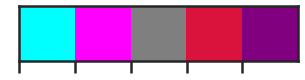

In [3]:
pal=sns.blend_palette(['cyan', 'magenta','gray','crimson','purple'], 5)
sns.palplot(pal)
sns.set_palette(pal)

In [60]:
plt.rcdefaults()

---

---

---

# Define the main functions first

In [4]:
def fun_1(objs):
    #load data and extract lick times
    rew_time_ls = []
    rew2_time_ls = []
    unrew_time_ls = []
    miss_ls= []
    for idx, x in enumerate(objs):
        if overall_order[idx] == '0':
            try:
                rew_time_ls.append(x.split("r")[1].split(" ")[0].split("u")[0])
            except:
                miss_ls.append(x.split("m")[1].split(" ")[0].split("u")[0])
        elif overall_order[idx] == '1':
            try:
                rew2_time_ls.append(x.split("z")[1].split(" ")[0].split("u")[0])
            except:
                miss_ls.append(x.split("m")[1].split(" ")[0].split("u")[0])            
        elif overall_order[idx] == '2':
            try:
                unrew_time_ls.append(x.split("o")[1].split(" ")[0].split("u")[0])
            except:
                print("Error{0}".format(idx))

#     print(len(rew_time_ls))
#     print(len(rew2_time_ls))
#     print(len(unrew_time_ls))
#     print(len(miss_ls))
    
#     total_trials = len(rew_time_ls)+len(rew2_time_ls)+len(unrew_time_ls)+len(miss_ls)
#     print(total_trials)
    
    return rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls

In [5]:
def fun_2(objs, rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls, inter_dur):
    #converting the string to an array
    rew_time_ar = np.array(rew_time_ls, dtype=np.float32)
    rew2_time_ar = np.array(rew2_time_ls, dtype=np.float32)
    unrew_time_ar = np.array(unrew_time_ls, dtype=np.float32)
    miss_time_ar = np.array(miss_ls, dtype=np.float32)

    #subtracting the stimulus duration
    rew_times = rew_time_ar - inter_dur
    rew2_times = rew2_time_ar - inter_dur
    unrew_times = unrew_time_ar - inter_dur
    miss_times = miss_time_ar - inter_dur

    #removing the 'u', 'r', 'z', 'o' and 'm' identifiers
    cleaned_objs = [ x.replace('u', ' ') for x in objs if 'u' in x ]

    rew_cleaned = [ x.replace('r',' ') for x in cleaned_objs if 'r' in x ]
    rew2_cleaned = [ x.replace('z',' ') for x in cleaned_objs if 'z' in x ]
    unrew_cleaned = [ x.replace('o',' ') for x in cleaned_objs if 'o' in x ]
    miss_cleaned = [ x.replace('m',' ') for x in cleaned_objs if 'm' in x]
    
    rew_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in rew_cleaned ]
    rew2_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in rew2_cleaned ]
    unrew_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in unrew_cleaned ]
    miss_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in miss_cleaned ]

    for idx, val in enumerate(rew_time_ar):
        rew_lick[idx] =  rew_lick[idx][rew_lick[idx] != val]
    for idx, val in enumerate(rew2_time_ar):
        rew2_lick[idx] =  rew2_lick[idx][rew2_lick[idx] != val]
    for idx, val in enumerate(unrew_time_ar):
        unrew_lick[idx] =  unrew_lick[idx][unrew_lick[idx] != val]
    for idx, val in enumerate(miss_time_ar):
        miss_lick[idx] = miss_lick[idx][miss_lick[idx] != val]
        
    # Create data frame for the rewarded - water - trials
    rew_df = pd.DataFrame(rew_lick).sub(rew_times, axis = 0)
    num_rew_tr = rew_df.shape[0]
    # Create data frame for the rewarded - no water - trials
    rew2_df = pd.DataFrame(rew2_lick).sub(rew2_times, axis = 0)
    num_rew2_tr = rew2_df.shape[0]
    # Create data frame for the unrewarded trials
    unrew_df = pd.DataFrame(unrew_lick).sub(unrew_times, axis = 0)
    num_unrew_tr = unrew_df.shape[0]
    # Create a data frame for the rewarded trials that had no licks during stim time
    miss_df = pd.DataFrame(miss_lick).sub(miss_times, axis = 0)
    num_miss_tr = miss_df.shape[0]

    df_licks = pd.concat([rew_df, miss_df, rew2_df, unrew_df], ignore_index=True) # ~~~~~~~~~~the order here is important
    df_licks.drop(df_licks.index[0], inplace=True)
    df_licks2 = pd.DataFrame(df_licks.stack())
    
    return df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr



In [6]:
def fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr):
    test = df_licks.to_numpy()

    list_of_licks_per_trial = []
    counter = 0
    for i in range(num_rew_tr+num_rew2_tr+num_unrew_tr+num_miss_tr-1):
        for value in test[i]:
            if value > -100000000 and value < 10000000:
                counter += 1
            else:
                break
        list_of_licks_per_trial.append(counter)
        counter = 0 
#     print(len(list_of_licks_per_trial))
#     print(list_of_licks_per_trial)

    list_reward_and_none = []
    for i, value in enumerate(list_of_licks_per_trial):
        for j in range(value):
            if i < num_rew_tr:       # Check if it's less than or less than or equal
                list_reward_and_none.append("rew")
            elif i > num_rew_tr and i < (num_rew_tr+num_rew2_tr):
                list_reward_and_none.append("rew2")
            elif i > (num_rew_tr+num_rew2_tr) and i < (num_rew_tr+num_rew2_tr+num_miss_tr):
                list_reward_and_none.append("miss")
            else:
                list_reward_and_none.append("unrew")
    
    df_licks2 = df_licks2.reset_index()
    df_licks2.columns = ["trial", "lick_idx", "lick_time"]

    df_licks2["stim_id"] = list_reward_and_none
    
#     print(df_licks2["stim_id"].unique())
    
    return df_licks2

---

---

---

# Combine 1sec and 2sec plots

In [7]:
#load data of all mice

path_1sec = r"U:\Data\zimmer94\Behavior\oper_rec_licks\1sec"
paradigm_1sec = 'RecInter'

matches_1sec = []
for root, dirnames, filenames in os.walk(path_1sec):
    for filename in filenames:
        if filename.endswith(('.pkl')) and paradigm_1sec in filename and "bad" not in filename and "bad" not in root:
            matches_1sec.append(os.path.join(root, filename))
print ("# of file matches:", len(matches_1sec))

matches_1sec[0]

# of file matches: 18


'U:\\Data\\zimmer94\\Behavior\\oper_rec_licks\\1sec\\CC067431_HP2_RecInter_2021-08-12_16-06-54.pkl'

In [8]:
path_2sec = r"U:\Data\zimmer94\Behavior\oper_rec_licks\2sec"
paradigm_2sec = 'RecInter2'

matches_2sec = []
for root, dirnames, filenames in os.walk(path_2sec):
    for filename in filenames:
        if filename.endswith(('.pkl')) and paradigm_2sec in filename and "bad" not in filename and "bad" not in root:
            matches_2sec.append(os.path.join(root, filename))
print ("# of file matches:", len(matches_2sec))

matches_2sec[0]

# of file matches: 15


'U:\\Data\\zimmer94\\Behavior\\oper_rec_licks\\2sec\\CC067431_HP2_RecInter2_2021-11-08_16-29-40.pkl'

# Define universal variables first

In [9]:
def combo_licks(big_df, group):
    if group == 'WT':
        group_df = big_df[big_df['group'] == 'WT']
    elif group == 'FX':
        group_df = big_df[big_df['group'] == 'FX']
        
    rew_df = group_df[group_df['stim_id'] == 'rew']
    rew2_df = group_df[group_df['stim_id'] == 'rew2']
    unrew_df = group_df[group_df['stim_id'] == 'unrew']
    
#     rew_df.loc[:, 'trial'] = rew_df['trial'].apply(lambda x:x-rew_df.trial.min())
#     rew2_df.loc[:, 'trial'] = rew2_df['trial'].apply(lambda x:x-rew2_df.trial.min())
#     unrew_df.loc[:, 'trial'] = unrew_df['trial'].apply(lambda x:x-99) #x:x-unrew_df.trial.min()
    
    return rew_df, rew2_df, unrew_df

In [10]:
#redo the cell below for 1sec and 2sec variables
stim_dur = 0.2
stim_lb = 0.0 #lower bound of stimulus time
stim_ub = 0.2 #upper bound of stimulus time

i1 = 1.0 + stim_dur
i2 = 2.0 + stim_dur

r1_l = stim_lb + i1
r1_u = stim_lb + i1 + 0.1
r2_l = stim_lb + i2
r2_u = stim_lb + i2 + 0.1

In [11]:
#Psuedo random presentation of the stimuli - 25 per row * 6 rows = 150 trials
# 0 -- drifting grating, rewarded stimulus, 100 trials
# 1 -- pink noise, unrewarded stimulus, 50 trials
stim_order = [0,1,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,
               0,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,1,0,0,0,0,1,
               0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,1,0,1,0,0,0,0,1,
               0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,
               1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,1,1,0,0,
               0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0]

#Psuedo random distribution of water to the rewarded stimuli
# 0 -- water given -- 80 times
# 1 -- no water given -- 20 times
rew_order = [0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,
               0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,
               0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,
               0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0]

In [12]:
overall_order = []
i=0
for idx,val in enumerate(stim_order):
    if val == 0:
        i = i+1
        if rew_order[i-1] == 0:
            overall_order.append('0') # rewH20
        elif rew_order[i-1] == 1:
            overall_order.append('1') # rewnoH20
    elif val == 1:
        overall_order.append('2')     # unrew
print(len(overall_order))

150


In [13]:
all_1sec_df = []
for fn in matches_1sec[:]:
    f=open(fn, 'rb')
    objs = []
    while 1:
        try:
            objs.append(pickle.load(f))
        except EOFError:
            break
    f.close()
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    cc = fn.split('\\')[-1].split('_')[0]
    hp = fn.split('\\')[-1].split('_')[1]
    combo = cc+hp
    if (cc == "CC082263") | (cc == "CC067489") | (cc == "CC082260") | (cc == "CC084621"):
        mouse_type = 'WT'
    elif (cc == "CC082257") | (cc == "CC067431") | (cc == "CC067432") | (cc == "CC082255"):
        mouse_type = 'FX'
    else:
        raise ValueError('Incorrect path, check the code...')
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls = fun_1(objs)
    df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr = fun_2(objs,
                                                                                    rew_time_ls, 
                                                                                    rew2_time_ls, 
                                                                                    unrew_time_ls, 
                                                                                    miss_ls,
                                                                                    i1)
    df_licks2 = fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr)
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    df_licks2['et'] = combo
    df_licks2['group'] = mouse_type
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    all_1sec_df.append(df_licks2) #first, append each mouse to a list
    
all_1sec_df = pd.concat(all_1sec_df) #second, transform the list to a dataFrame

In [14]:
all_2sec_df = []
for fn in matches_2sec[:]:
    f=open(fn, 'rb')
    objs = []
    while 1:
        try:
            objs.append(pickle.load(f))
        except EOFError:
            break
    f.close()
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    cc = fn.split('\\')[-1].split('_')[0]
    hp = fn.split('\\')[-1].split('_')[1]
    combo = cc+hp
    if (cc == "CC082263") | (cc == "CC067489") | (cc == "CC082260") | (cc == "CC084621"):
        mouse_type = 'WT'
    elif (cc == "CC082257") | (cc == "CC067431") | (cc == "CC067432") | (cc == "CC082255"):
        mouse_type = 'FX'
    else:
        raise ValueError('Incorrect path, check the code...')
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls = fun_1(objs)
    df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr = fun_2(objs,
                                                                                    rew_time_ls, 
                                                                                    rew2_time_ls, 
                                                                                    unrew_time_ls, 
                                                                                    miss_ls,
                                                                                    i2)
    df_licks2 = fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr)
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    df_licks2['et'] = combo
    df_licks2['group'] = mouse_type
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    all_2sec_df.append(df_licks2) #first, append each mouse to a list
    
all_2sec_df = pd.concat(all_2sec_df) #second, transform the list to a dataFrame

In [15]:
wt1_rew, wt1_rew2, wt1_unrew = combo_licks(all_1sec_df, group='WT')
fx1_rew, fx1_rew2, fx1_unrew = combo_licks(all_1sec_df, group='FX')

wt2_rew, wt2_rew2, wt2_unrew = combo_licks(all_2sec_df, group='WT')
fx2_rew, fx2_rew2, fx2_unrew = combo_licks(all_2sec_df, group='FX')

In [88]:
wt11 = wt1_rew.lick_time.values
wt12 = wt1_rew2.lick_time.values
wt13 = wt1_unrew.lick_time.values
fx11 = fx1_rew.lick_time.values
fx12 = fx1_rew2.lick_time.values
fx13 = fx1_unrew.lick_time.values

wt21 = wt2_rew.lick_time.values
wt22 = wt2_rew2.lick_time.values
wt23 = wt2_unrew.lick_time.values
fx21 = fx2_rew.lick_time.values
fx22 = fx2_rew2.lick_time.values
fx23 = fx2_unrew.lick_time.values

pt1 = 'rew'
pt2 = 'rew2'
pt3 = 'unrew'

In [124]:
# only run this if I want to cut the lick times to be within a given window

low = -2
up = 8

wt11 = wt11[(wt11>=low) & (wt11<=up)]
wt12 = wt12[(wt12>=low) & (wt12<=up)]
wt13 = wt13[(wt13>=low) & (wt13<=up)]
wt21 = wt21[(wt21>=low) & (wt21<=up)]
wt22 = wt22[(wt22>=low) & (wt22<=up)]
wt23 = wt23[(wt23>=low) & (wt23<=up)]

fx11 = fx11[(fx11>=low) & (fx11<=up)]
fx12 = fx12[(fx12>=low) & (fx12<=up)]
fx13 = fx13[(fx13>=low) & (fx13<=up)]
fx21 = fx21[(fx21>=low) & (fx21<=up)]
fx22 = fx22[(fx22>=low) & (fx22<=up)]
fx23 = fx23[(fx23>=low) & (fx23<=up)]

### WT plots

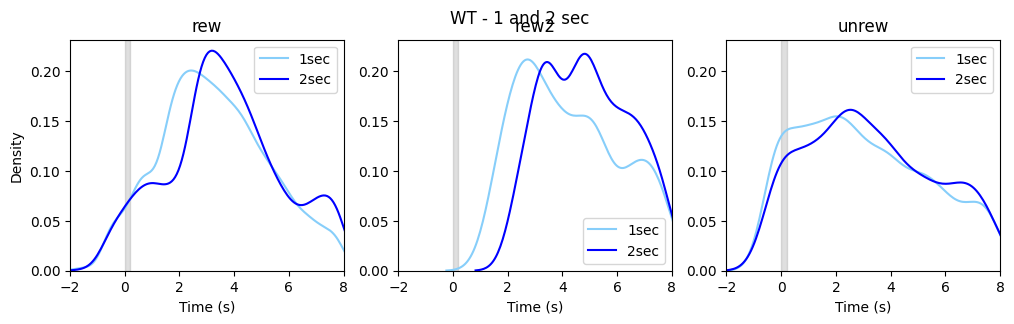

In [125]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 3.0 # y dimension

plt.suptitle('WT - 1 and 2 sec')

ax1 = plt.subplot(131)
sns.kdeplot(wt11, label='1sec', color='lightskyblue')
sns.kdeplot(wt21, label='2sec', color='blue')
plt.legend()
plt.title(pt1)
plt.xlim([-2,8])
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.xlabel('Time (s)')

ax2 = plt.subplot(132, sharex=ax1, sharey=ax1)
sns.kdeplot(wt12, label='1sec', color='lightskyblue')
sns.kdeplot(wt22, label='2sec', color='blue')
plt.legend()
plt.title(pt2)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.xlabel('Time (s)')

ax3 = plt.subplot(133, sharex=ax1, sharey=ax1)
sns.kdeplot(wt13, label='1sec', color='lightskyblue')
sns.kdeplot(wt23, label='2sec', color='blue')
plt.legend()
plt.title(pt3)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.xlabel('Time (s)')

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\averaged\wt_12sec_kde_v2.pdf", transparent=True)

plt.show()

### FX plots

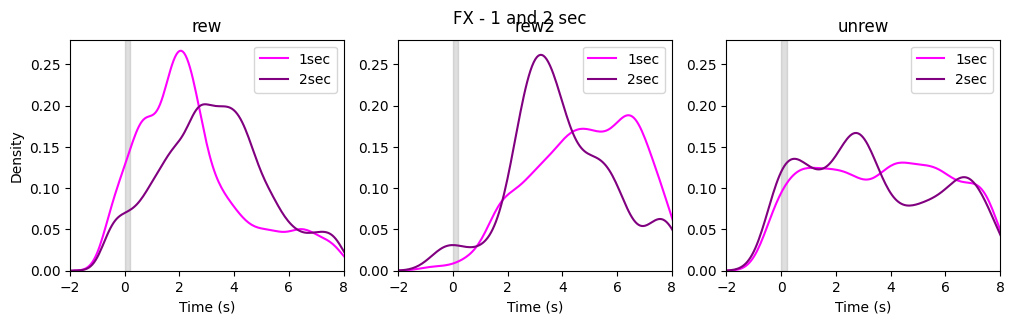

In [126]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 3.0 # y dimension

plt.suptitle('FX - 1 and 2 sec')

ax1 = plt.subplot(131)
sns.kdeplot(fx11, label='1sec', color='magenta')
sns.kdeplot(fx21, label='2sec', color='purple')
plt.legend()
plt.title(pt1)
plt.xlim([-2,8])
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.xlabel('Time (s)')

ax2 = plt.subplot(132, sharex=ax1, sharey=ax1)
sns.kdeplot(fx12, label='1sec', color='magenta')
sns.kdeplot(fx22, label='2sec', color='purple')
plt.legend()
plt.title(pt2)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.xlabel('Time (s)')

ax3 = plt.subplot(133, sharex=ax1, sharey=ax1)
sns.kdeplot(fx13, label='1sec', color='magenta')
sns.kdeplot(fx23, label='2sec', color='purple')
plt.legend()
plt.title(pt3)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.xlabel('Time (s)')

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\averaged\fx_12sec_kde_v2.pdf", transparent=True)

plt.show()

### Cumulative distribution kde plots

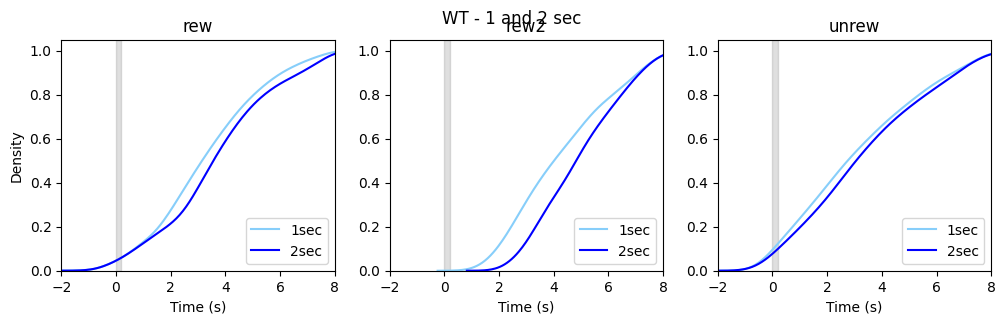

In [127]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 3.0 # y dimension

plt.suptitle('WT - 1 and 2 sec')

ax1 = plt.subplot(131)
sns.kdeplot(wt11, label='1sec', color='lightskyblue', cumulative=True)
sns.kdeplot(wt21, label='2sec', color='blue', cumulative=True)
plt.legend()
plt.title(pt1)
plt.xlim([-2,8])
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.xlabel('Time (s)')

ax2 = plt.subplot(132, sharex=ax1, sharey=ax1)
sns.kdeplot(wt12, label='1sec', color='lightskyblue', cumulative=True)
sns.kdeplot(wt22, label='2sec', color='blue', cumulative=True)
plt.legend()
plt.title(pt2)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.xlabel('Time (s)')

ax3 = plt.subplot(133, sharex=ax1, sharey=ax1)
sns.kdeplot(wt13, label='1sec', color='lightskyblue', cumulative=True)
sns.kdeplot(wt23, label='2sec', color='blue', cumulative=True)
plt.legend()
plt.title(pt3)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.xlabel('Time (s)')

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\averaged\wt_12sec_cumulative_v2.pdf", transparent=True)

plt.show()

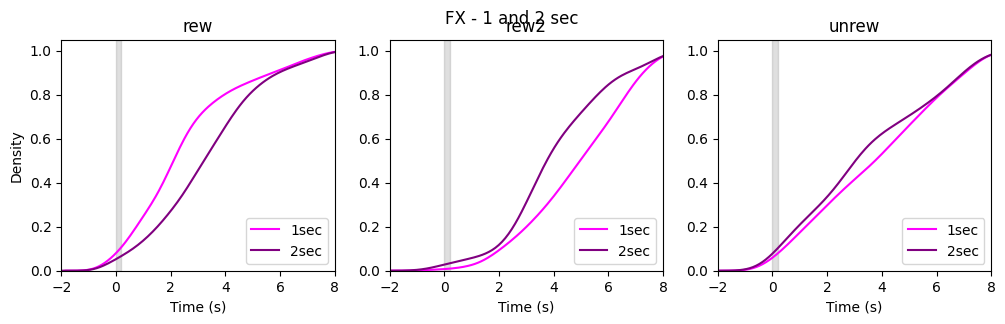

In [129]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 3.0 # y dimension

plt.suptitle('FX - 1 and 2 sec')

ax1 = plt.subplot(131)
sns.kdeplot(fx11, label='1sec', color='magenta', cumulative=True)
sns.kdeplot(fx21, label='2sec', color='purple', cumulative=True)
plt.legend()
plt.title(pt1)
plt.xlim([-2,8])
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.xlabel('Time (s)')

ax2 = plt.subplot(132, sharex=ax1, sharey=ax1)
sns.kdeplot(fx12, label='1sec', color='magenta', cumulative=True)
sns.kdeplot(fx22, label='2sec', color='purple', cumulative=True)
plt.legend()
plt.title(pt2)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.xlabel('Time (s)')

ax3 = plt.subplot(133, sharex=ax1, sharey=ax1)
sns.kdeplot(fx13, label='1sec', color='magenta', cumulative=True)
sns.kdeplot(fx23, label='2sec', color='purple', cumulative=True)
plt.legend()
plt.title(pt3)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.xlabel('Time (s)')

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\averaged\fx_12sec_cumulative_v2.pdf", transparent=True)

plt.show()

In [128]:
rew_stats = stats.ks_2samp(wt11, wt21)
rew2_stats = stats.ks_2samp(wt12, wt22)
unrew_stats = stats.ks_2samp(wt13, wt23)

print('WT mice - 1 and 2 sec')
print('rewarded: ')
print(rew_stats)
print('rewarded without: ')
print(rew2_stats)
print('unrewarded: ')
print(unrew_stats)

WT mice - 1 and 2 sec
rewarded: 
KstestResult(statistic=0.11431281519365806, pvalue=1.5543122344752192e-15)
rewarded without: 
KstestResult(statistic=0.24742163921960028, pvalue=2.7510771438699066e-11)
unrewarded: 
KstestResult(statistic=0.0687826237798115, pvalue=0.0004464878656715854)


In [130]:
rew_stats = stats.ks_2samp(fx11, fx21)
rew2_stats = stats.ks_2samp(fx12, fx22)
unrew_stats = stats.ks_2samp(fx13, fx23)

print('FX mice - 1 and 2 sec')
print('rewarded: ')
print(rew_stats)
print('rewarded without: ')
print(rew2_stats)
print('unrewarded: ')
print(unrew_stats)

FX mice - 1 and 2 sec
rewarded: 
KstestResult(statistic=0.2631291092573531, pvalue=3.3306690738754696e-15)
rewarded without: 
KstestResult(statistic=0.25390560893618147, pvalue=1.5515566624306005e-17)
unrewarded: 
KstestResult(statistic=0.1197967386480512, pvalue=2.2366663086354533e-16)


### WT and FX histograms

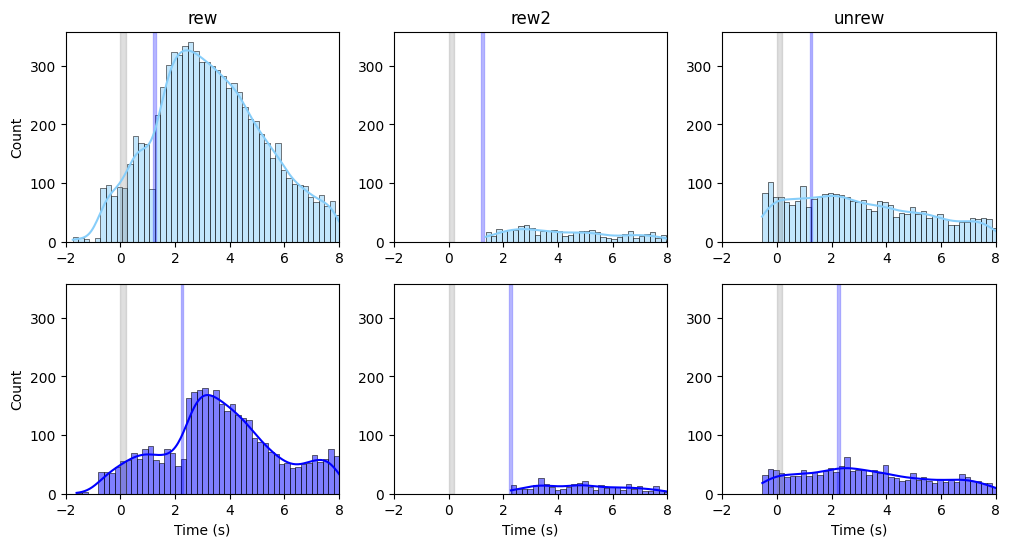

In [133]:
# plt.rcdefaults()

stat_option = 'count'
# plt.suptitle('All mice - Averaged licks')

fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 6.0 # y dimension

plt.tight_layout()
# plt.rcParams['figure.autolayout'] = True
# plt.rcParams['figure.constrained_layout.use'] = True
# plt.rcParams.keys() # shows the multiple options for the above layout setting

ax1 = plt.subplot(231)
sns.histplot(wt11, binwidth = 0.2, color = 'lightskyblue', stat = stat_option, kde = True)
plt.title(pt1)
plt.xlim([-2,8])
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r1_l, r1_u, color='blue', alpha=0.25)

ax2 = plt.subplot(232, sharex=ax1, sharey=ax1)
sns.histplot(wt12, binwidth = 0.2, color = 'lightskyblue', stat = stat_option, kde = True)
plt.title(pt2)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r1_l, r1_u, color='blue', alpha=0.25)

ax3 = plt.subplot(233, sharex=ax1, sharey=ax1)
sns.histplot(wt13, binwidth = 0.2, color = 'lightskyblue', stat = stat_option, kde = True)
plt.title(pt3)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r1_l, r1_u, color='blue', alpha=0.25)

ax4 = plt.subplot(234, sharex=ax1, sharey=ax1)
sns.histplot(wt21, binwidth = 0.2, color = 'blue', stat = stat_option, kde = True)
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r2_l, r2_u, color='blue', alpha=0.25)
plt.xlabel('Time (s)')

ax5 = plt.subplot(235, sharex=ax1, sharey=ax1)
sns.histplot(wt22, binwidth = 0.2, color = 'blue', stat = stat_option, kde = True)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r2_l, r2_u, color='blue', alpha=0.25)
plt.xlabel('Time (s)')

ax6 = plt.subplot(236, sharex=ax1, sharey=ax1)
sns.histplot(wt23, binwidth = 0.2, color = 'blue', stat = stat_option, kde = True)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r2_l, r2_u, color='blue', alpha=0.25)
plt.xlabel('Time (s)')

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\averaged\wt_12sec_hist.pdf", transparent=True)

plt.show()

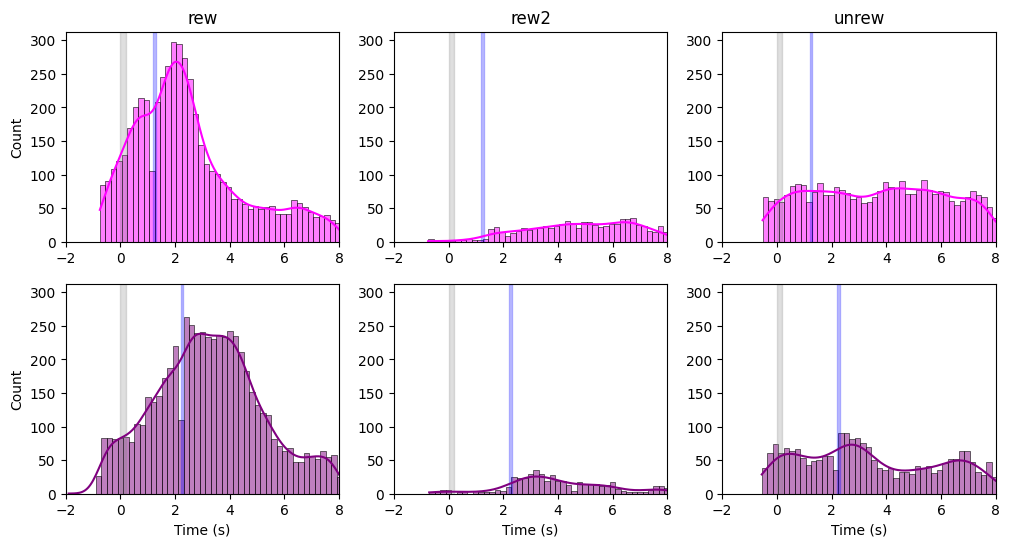

In [134]:
# plt.rcdefaults()

stat_option = 'count'
# plt.suptitle('All mice - Averaged licks')

fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 6.0 # y dimension

plt.tight_layout()
# plt.rcParams['figure.autolayout'] = True
# plt.rcParams['figure.constrained_layout.use'] = True
# plt.rcParams.keys() # shows the multiple options for the above layout setting

ax1 = plt.subplot(231)
sns.histplot(fx11, binwidth = 0.2, color = 'magenta', stat = stat_option, kde = True)
plt.title(pt1)
plt.xlim([-2,8])
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r1_l, r1_u, color='blue', alpha=0.25)

ax2 = plt.subplot(232, sharex=ax1, sharey=ax1)
sns.histplot(fx12, binwidth = 0.2, color = 'magenta', stat = stat_option, kde = True)
plt.title(pt2)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r1_l, r1_u, color='blue', alpha=0.25)

ax3 = plt.subplot(233, sharex=ax1, sharey=ax1)
sns.histplot(fx13, binwidth = 0.2, color = 'magenta', stat = stat_option, kde = True)
plt.title(pt3)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r1_l, r1_u, color='blue', alpha=0.25)

ax4 = plt.subplot(234, sharex=ax1, sharey=ax1)
sns.histplot(fx21, binwidth = 0.2, color = 'purple', stat = stat_option, kde = True)
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r2_l, r2_u, color='blue', alpha=0.25)
plt.xlabel('Time (s)')

ax5 = plt.subplot(235, sharex=ax1, sharey=ax1)
sns.histplot(fx22, binwidth = 0.2, color = 'purple', stat = stat_option, kde = True)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r2_l, r2_u, color='blue', alpha=0.25)
plt.xlabel('Time (s)')

ax6 = plt.subplot(236, sharex=ax1, sharey=ax1)
sns.histplot(fx23, binwidth = 0.2, color = 'purple', stat = stat_option, kde = True)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r2_l, r2_u, color='blue', alpha=0.25)
plt.xlabel('Time (s)')

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\averaged\fx_12sec_hist.pdf", transparent=True)

plt.show()

# Normalize the lick counts by the # of trials

In [135]:
def norm_hist(rew_arr, rew2_arr, unrew_arr, my_bins=150):
    h1, b1 = np.histogram(rew_arr, bins=my_bins)
    h2, b2 = np.histogram(rew2_arr, bins=my_bins)
    h3, b3 = np.histogram(unrew_arr, bins=my_bins)
    
    h1 = h1/80 #normalizing the lick counts by num of trials per situation
    h2 = h2/20
    h3 = h3/50
    
    c1 = (b1[:-1]+b1[1:])/2
    c2 = (b2[:-1]+b2[1:])/2
    c3 = (b3[:-1]+b3[1:])/2
    
    return h1, h2, h3, c1, c2, c3

In [228]:
num_bins = 150
my_width = 0.25

h_wt11, h_wt12, h_wt13, wt1c1, wt1c2, wt1c3 = norm_hist(wt11, wt12, wt13, my_bins=num_bins)
h_wt21, h_wt22, h_wt23, wt2c1, wt2c2, wt2c3 = norm_hist(wt21, wt22, wt23, my_bins=num_bins)

h_fx11, h_fx12, h_fx13, fx1c1, fx1c2, fx1c3 = norm_hist(fx11, fx12, fx13, my_bins=num_bins)
h_fx21, h_fx22, h_fx23, fx2c1, fx2c2, fx2c3 = norm_hist(fx21, fx22, fx23, my_bins=num_bins)

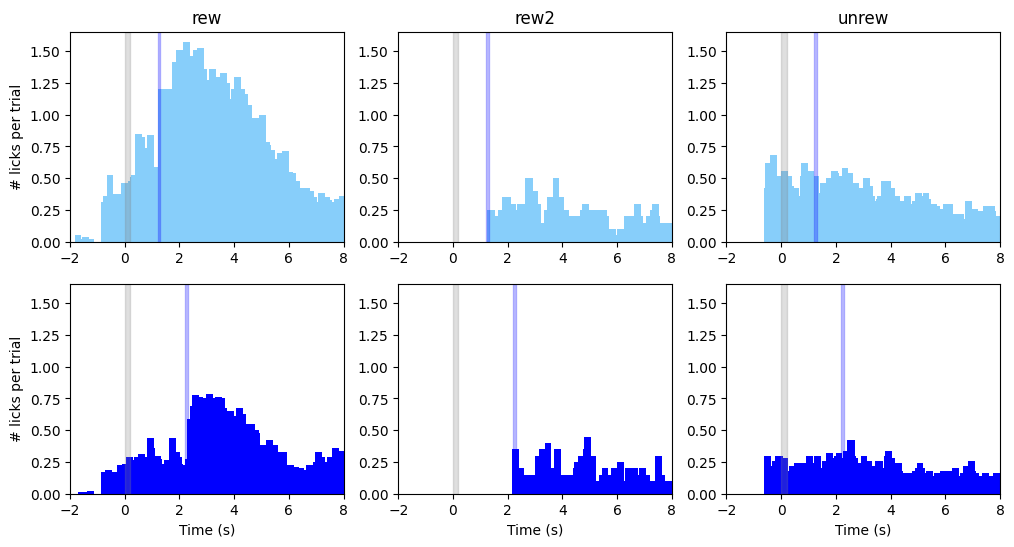

In [231]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 6.0 # y dimension

plt.tight_layout()
# plt.rcParams['figure.autolayout'] = True
# plt.rcParams['figure.constrained_layout.use'] = True
# plt.rcParams.keys() # shows the multiple options for the above layout setting

ax1 = plt.subplot(231)
plt.bar(wt1c1, h_wt11, width=my_width, color='lightskyblue')
plt.title(pt1)
plt.ylabel('# licks per trial')
plt.xlim([-2,8])
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r1_l, r1_u, color='blue', alpha=0.25)

ax2 = plt.subplot(232, sharex=ax1, sharey=ax1)
plt.bar(wt1c2, h_wt12, width=my_width, color='lightskyblue')
plt.title(pt2)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r1_l, r1_u, color='blue', alpha=0.25)

ax3 = plt.subplot(233, sharex=ax1, sharey=ax1)
plt.bar(wt1c3, h_wt13, width=my_width, color='lightskyblue')
plt.title(pt3)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r1_l, r1_u, color='blue', alpha=0.25)

ax4 = plt.subplot(234, sharex=ax1, sharey=ax1)
plt.bar(wt2c1, h_wt21, width=my_width, color='blue')
plt.xlabel('Time (s)')
plt.ylabel('# licks per trial')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r2_l, r2_u, color='blue', alpha=0.25)

ax5 = plt.subplot(235, sharex=ax1, sharey=ax1)
plt.bar(wt2c2, h_wt22, width=my_width, color='blue')
plt.ylabel('')
plt.xlabel('Time (s)')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r2_l, r2_u, color='blue', alpha=0.25)

ax6 = plt.subplot(236, sharex=ax1, sharey=ax1)
plt.bar(wt2c3, h_wt23, width=my_width, color='blue')
plt.ylabel('')
plt.xlabel('Time (s)')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r2_l, r2_u, color='blue', alpha=0.25)

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\averaged\wt_trialavg_hist.pdf", transparent=True)

plt.show()

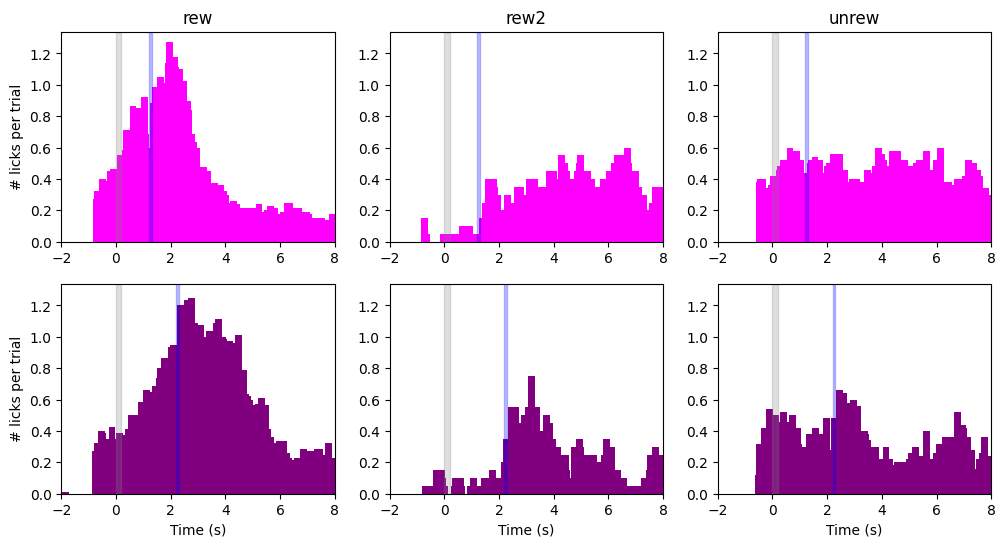

In [232]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 6.0 # y dimension

plt.tight_layout()
# plt.rcParams['figure.autolayout'] = True
# plt.rcParams['figure.constrained_layout.use'] = True
# plt.rcParams.keys() # shows the multiple options for the above layout setting

ax1 = plt.subplot(231)
plt.bar(fx1c1, h_fx11, width=my_width, color='magenta')
plt.title(pt1)
plt.ylabel('# licks per trial')
plt.xlim([-2,8])
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r1_l, r1_u, color='blue', alpha=0.25)

ax2 = plt.subplot(232, sharex=ax1, sharey=ax1)
plt.bar(fx1c2, h_fx12, width=my_width, color='magenta')
plt.title(pt2)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r1_l, r1_u, color='blue', alpha=0.25)

ax3 = plt.subplot(233, sharex=ax1, sharey=ax1)
plt.bar(fx1c3, h_fx13, width=my_width, color='magenta')
plt.title(pt3)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r1_l, r1_u, color='blue', alpha=0.25)

ax4 = plt.subplot(234, sharex=ax1, sharey=ax1)
plt.bar(fx2c1, h_fx21, width=my_width, color='purple')
plt.xlabel('Time (s)')
plt.ylabel('# licks per trial')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r2_l, r2_u, color='blue', alpha=0.25)

ax5 = plt.subplot(235, sharex=ax1, sharey=ax1)
plt.bar(fx2c2, h_fx22, width=my_width, color='purple')
plt.ylabel('')
plt.xlabel('Time (s)')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r2_l, r2_u, color='blue', alpha=0.25)

ax6 = plt.subplot(236, sharex=ax1, sharey=ax1)
plt.bar(fx2c3, h_fx23, width=my_width, color='purple')
plt.ylabel('')
plt.xlabel('Time (s)')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(r2_l, r2_u, color='blue', alpha=0.25)

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\averaged\fx_trialavg_hist.pdf", transparent=True)

plt.show()

In [213]:
# def get_cumsum(h_rew, h_rew2, h_unrew):
#     out1 = np.cumsum(h_rew)
#     out2 = np.cumsum(h_rew2)
#     out3 = np.cumsum(h_unrew)
    
#     return out1, out2, out3

In [214]:
def get_cumsum(h_rew, h_rew2, h_unrew):
    foo1 = np.cumsum(h_rew)
    foo2 = np.cumsum(h_rew2)
    foo3 = np.cumsum(h_unrew)
    
    out1 = foo1/np.max(foo1)
    out2 = foo2/np.max(foo2)
    out3 = foo3/np.max(foo3)
    
    return out1, out2, out3

In [215]:
cs_wt11, cs_wt12, cs_wt13 = get_cumsum(h_wt11, h_wt12, h_wt13)
cs_wt21, cs_wt22, cs_wt23 = get_cumsum(h_wt21, h_wt22, h_wt23)

cs_fx11, cs_fx12, cs_fx13 = get_cumsum(h_fx11, h_fx12, h_fx13)
cs_fx21, cs_fx22, cs_fx23 = get_cumsum(h_fx21, h_fx22, h_fx23)

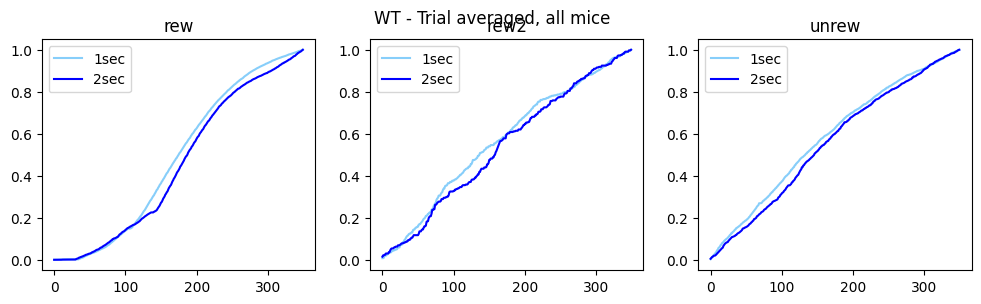

In [216]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 3.0 # y dimension

plt.suptitle('WT - Trial averaged, all mice')

ax1 = plt.subplot(131)
plt.plot(cs_wt11, label='1sec', color='lightskyblue')
plt.plot(cs_wt21, label='2sec', color='blue')
plt.legend()
plt.title(pt1)

ax2 = plt.subplot(132, sharex=ax1, sharey=ax1)
plt.plot(cs_wt12, label='1sec', color='lightskyblue')
plt.plot(cs_wt22, label='2sec', color='blue')
plt.legend()
plt.title(pt2)
plt.ylabel('')

ax3 = plt.subplot(133, sharex=ax1, sharey=ax1)
plt.plot(cs_wt13, label='1sec', color='lightskyblue')
plt.plot(cs_wt23, label='2sec', color='blue')
plt.legend()
plt.title(pt3)
plt.ylabel('')

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\averaged\wt_12sec_cumulative_v2.pdf", transparent=True)

plt.show()

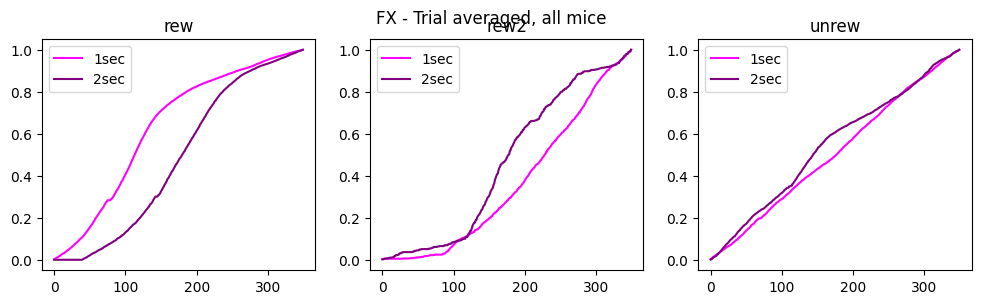

In [217]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 3.0 # y dimension

plt.suptitle('FX - Trial averaged, all mice')

ax1 = plt.subplot(131)
plt.plot(cs_fx11, label='1sec', color='magenta')
plt.plot(cs_fx21, label='2sec', color='purple')
plt.legend()
plt.title(pt1)

ax2 = plt.subplot(132, sharex=ax1, sharey=ax1)
plt.plot(cs_fx12, label='1sec', color='magenta')
plt.plot(cs_fx22, label='2sec', color='purple')
plt.legend()
plt.title(pt2)
plt.ylabel('')

ax3 = plt.subplot(133, sharex=ax1, sharey=ax1)
plt.plot(cs_fx13, label='1sec', color='magenta')
plt.plot(cs_fx23, label='2sec', color='purple')
plt.legend()
plt.title(pt3)
plt.ylabel('')

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\averaged\fx_12sec_cumulative_v2.pdf", transparent=True)

plt.show()

In [218]:
rew_stats = stats.ks_2samp(cs_wt11, cs_wt21)
rew2_stats = stats.ks_2samp(cs_wt12, cs_wt22)
unrew_stats = stats.ks_2samp(cs_wt13, cs_wt23)

print('WT mice - 1 and 2 sec')
print('rewarded: ')
print(rew_stats)
print('rewarded without: ')
print(rew2_stats)
print('unrewarded: ')
print(unrew_stats)

WT mice - 1 and 2 sec
rewarded: 
KstestResult(statistic=0.07714285714285714, pvalue=0.2489030992681408)
rewarded without: 
KstestResult(statistic=0.08571428571428572, pvalue=0.1528671075581177)
unrewarded: 
KstestResult(statistic=0.05142857142857143, pvalue=0.7444477161091746)


In [219]:
rew_stats = stats.ks_2samp(cs_fx11, cs_fx21)
rew2_stats = stats.ks_2samp(cs_fx12, cs_fx22)
unrew_stats = stats.ks_2samp(cs_fx13, cs_fx23)

print('FX mice - 1 and 2 sec')
print('rewarded: ')
print(rew_stats)
print('rewarded without: ')
print(rew2_stats)
print('unrewarded: ')
print(unrew_stats)

FX mice - 1 and 2 sec
rewarded: 
KstestResult(statistic=0.20285714285714285, pvalue=1.0266963072037401e-06)
rewarded without: 
KstestResult(statistic=0.18285714285714286, pvalue=1.5747515517642453e-05)
unrewarded: 
KstestResult(statistic=0.10857142857142857, pvalue=0.03223212569570341)


### wilcoxon signed rank test

In [220]:
rew_stats = stats.wilcoxon(cs_wt11, cs_wt21)
rew2_stats = stats.wilcoxon(cs_wt12, cs_wt22)
unrew_stats = stats.wilcoxon(cs_wt13, cs_wt23)

print('rewarded: ')
print(rew_stats)
print('rewarded without: ')
print(rew2_stats)
print('unrewarded: ')
print(unrew_stats)

rewarded: 
WilcoxonResult(statistic=6399.0, pvalue=1.688205097026063e-37)
rewarded without: 
WilcoxonResult(statistic=7437.0, pvalue=1.7356170880083172e-34)
unrewarded: 
WilcoxonResult(statistic=883.0, pvalue=1.0670548344841361e-55)


In [221]:
rew_stats = stats.wilcoxon(cs_fx11, cs_fx21)
rew2_stats = stats.wilcoxon(cs_fx12, cs_fx22)
unrew_stats = stats.wilcoxon(cs_fx13, cs_fx23)

print('rewarded: ')
print(rew_stats)
print('rewarded without: ')
print(rew2_stats)
print('unrewarded: ')
print(unrew_stats)

rewarded: 
WilcoxonResult(statistic=0.0, pvalue=5.908006057470862e-59)
rewarded without: 
WilcoxonResult(statistic=1027.0, pvalue=3.546548458863287e-55)
unrewarded: 
WilcoxonResult(statistic=2108.0, pvalue=2.450944516680854e-51)
